In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
img     = cv2.imread("test.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [10]:
#  Remove Noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

In [11]:
#  Sobel
sobel_x        = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobel_y        = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = np.uint8(np.clip(cv2.magnitude(sobel_x, sobel_y), 0, 255))

In [12]:
#  Laplacian
laplacian = np.uint8(np.absolute(cv2.Laplacian(blurred, cv2.CV_64F)))

In [15]:
#  Canny with different threshold
canny_low  = cv2.Canny(blurred, 30,  100)   # find more edges
canny_mid  = cv2.Canny(blurred, 50,  150)   # balance
canny_high = cv2.Canny(blurred, 100, 200)   # clear edges

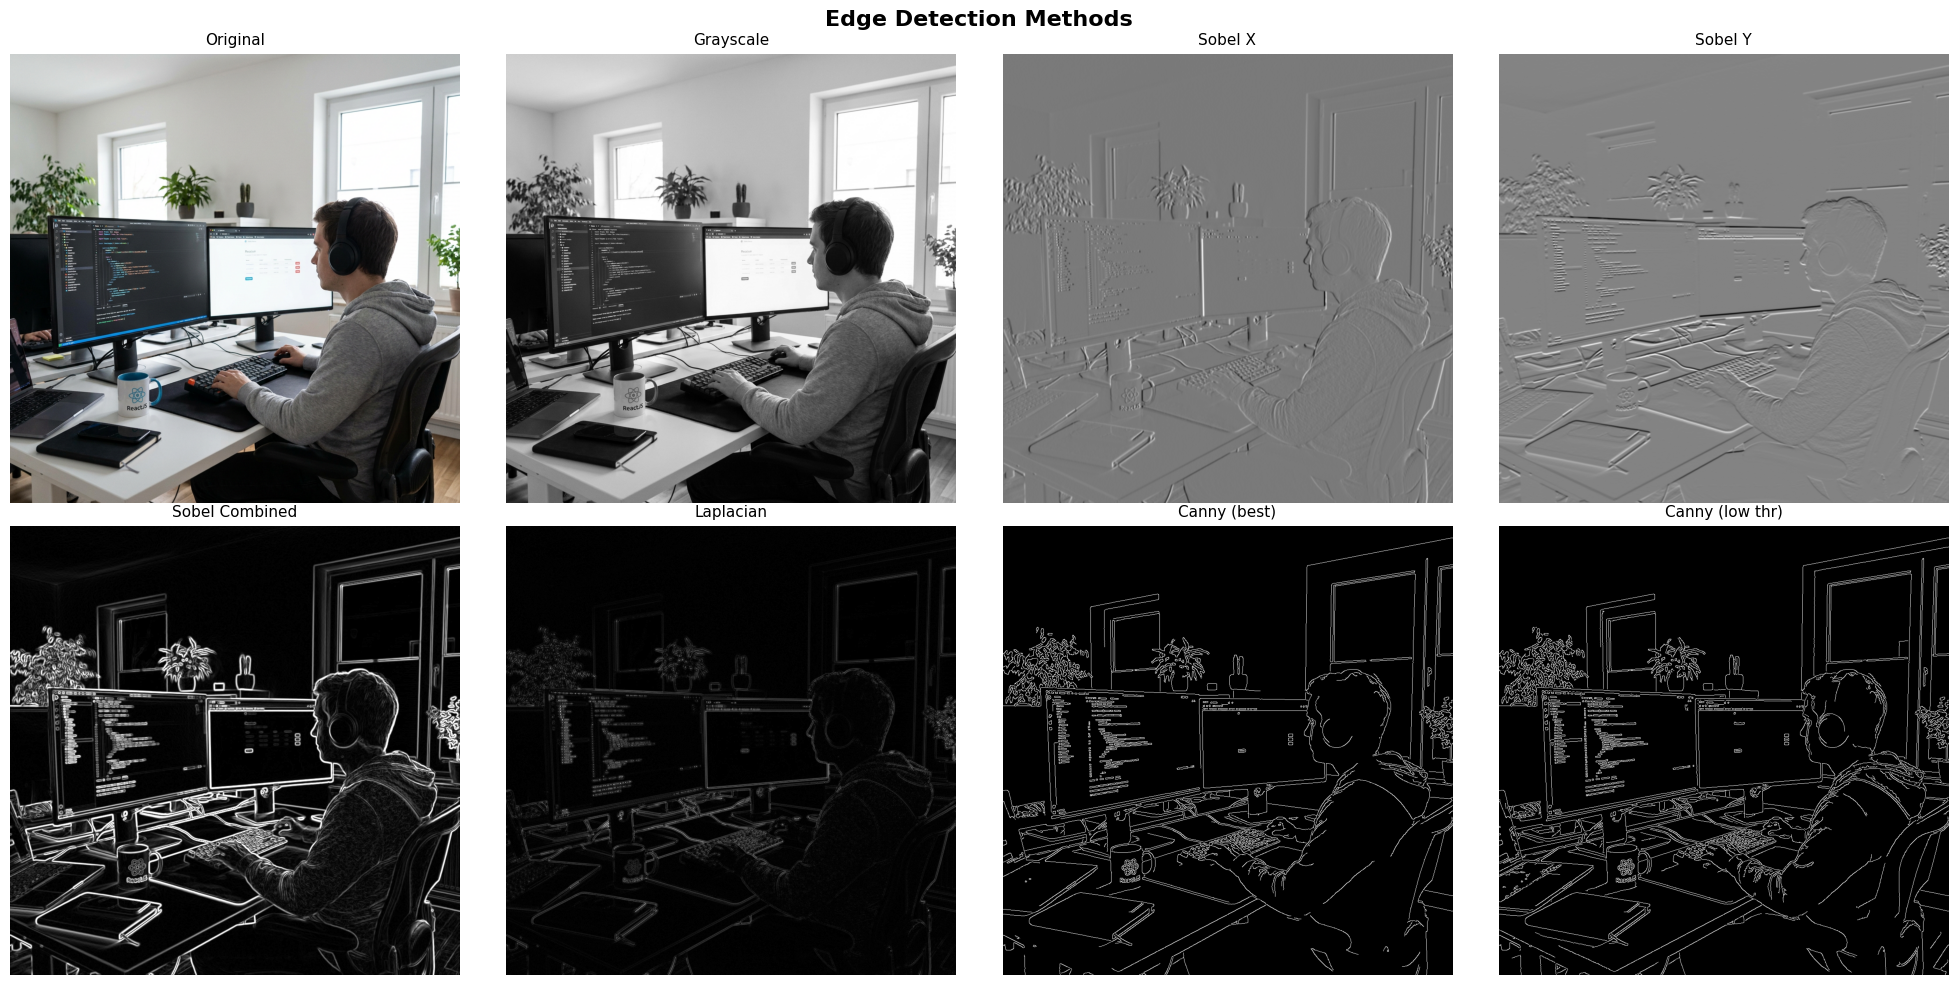

In [14]:
#Results
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Edge Detection Methods", fontsize=16, fontweight="bold")

data = [
    (img_rgb,        "Original",        None),
    (gray,           "Grayscale",       "gray"),
    (sobel_x,        "Sobel X",         "gray"),
    (sobel_y,        "Sobel Y",         "gray"),
    (sobel_combined, "Sobel Combined",  "gray"),
    (laplacian,      "Laplacian",       "gray"),
    (canny_mid,      "Canny (best)",    "gray"),
    (canny_low,      "Canny (low thr)", "gray"),
]

for ax, (image, title, cmap) in zip(axes.flat, data):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [16]:
# Interactive Slider in canny
from ipywidgets import interact
import ipywidgets as widgets

def show_canny(t1, t2):
    edges = cv2.Canny(blurred, t1, t2)
    plt.figure(figsize=(8, 6))
    plt.imshow(edges, cmap="gray")
    plt.title(f"Canny — t1={t1}, t2={t2}")
    plt.axis("off")
    plt.show()

interact(show_canny,
         t1=widgets.IntSlider(min=0,   max=200, step=10, value=50),
         t2=widgets.IntSlider(min=100, max=400, step=10, value=150))

interactive(children=(IntSlider(value=50, description='t1', max=200, step=10), IntSlider(value=150, descriptio…

<function __main__.show_canny(t1, t2)>